In [1]:
# Cell 1 — Star list (primary input)
# This is the only cell that needs editing to add a new star.
# type: "variable" (default) — displayName must resolve via the VSX "ident" lookup
#       (e.g. "CY Aqr", "W UMa").
#       "standard_field" — a non-variable AAVSO Standard Field used for transform
#       calculations (e.g. "M11"); displayName must match an AAVSO standard field
#       name exactly (see https://www.aavso.org/aavso-standard-fields).
# objectId is a stable lowercase identifier derived from displayName unless overridden here.

stars = [
    {"displayName": "CY Aqr", "type": "variable"},
    {"displayName": "YZ Boo", "type": "variable"},
    {"displayName": "W UMa", "type": "variable"},
    {"displayName": "SA110", "type": "standard_field"},
]

In [2]:
# Cell 2 — Imports & config

import json
import re
import urllib.request
import urllib.parse
import pandas as pd
from astropy.coordinates import SkyCoord, get_constellation
import astropy.units as u

VSX_API_URL = "https://www.aavso.org/vsx/index.php"
OUTPUT_FILE = "mobile/vs.json"

In [3]:
# Cell 3 — Lookup maps

# IAU 3-letter abbreviation -> full constellation name (same table as dso_catalog.ipynb)
CONSTELLATION_NAMES = {
    "And": "Andromeda",       "Ant": "Antlia",          "Aps": "Apus",
    "Aqr": "Aquarius",        "Aql": "Aquila",           "Ara": "Ara",
    "Ari": "Aries",           "Aur": "Auriga",           "Boo": "Boötes",
    "Cae": "Caelum",          "Cam": "Camelopardalis",   "Cnc": "Cancer",
    "CVn": "Canes Venatici",  "CMa": "Canis Major",      "CMi": "Canis Minor",
    "Cap": "Capricornus",     "Car": "Carina",            "Cas": "Cassiopeia",
    "Cen": "Centaurus",       "Cep": "Cepheus",          "Cet": "Cetus",
    "Cha": "Chamaeleon",      "Cir": "Circinus",         "Col": "Columba",
    "Com": "Coma Berenices",  "CrA": "Corona Australis", "CrB": "Corona Borealis",
    "Crv": "Corvus",          "Crt": "Crater",            "Cru": "Crux",
    "Cyg": "Cygnus",          "Del": "Delphinus",        "Dor": "Dorado",
    "Dra": "Draco",           "Equ": "Equuleus",         "Eri": "Eridanus",
    "For": "Fornax",          "Gem": "Gemini",            "Gru": "Grus",
    "Her": "Hercules",        "Hor": "Horologium",       "Hya": "Hydra",
    "Hyi": "Hydrus",          "Ind": "Indus",             "Lac": "Lacerta",
    "Leo": "Leo",             "LMi": "Leo Minor",         "Lep": "Lepus",
    "Lib": "Libra",           "Lup": "Lupus",             "Lyn": "Lynx",
    "Lyr": "Lyra",            "Men": "Mensa",             "Mic": "Microscopium",
    "Mon": "Monoceros",       "Mus": "Musca",             "Nor": "Norma",
    "Oct": "Octans",          "Oph": "Ophiuchus",         "Ori": "Orion",
    "Pav": "Pavo",            "Peg": "Pegasus",           "Per": "Perseus",
    "Phe": "Phoenix",         "Pic": "Pictor",            "Psc": "Pisces",
    "PsA": "Piscis Austrinus","Pup": "Puppis",            "Pyx": "Pyxis",
    "Ret": "Reticulum",       "Sge": "Sagitta",           "Sgr": "Sagittarius",
    "Sco": "Scorpius",        "Scl": "Sculptor",          "Sct": "Scutum",
    "Se1": "Serpens Caput",   "Se2": "Serpens Cauda",     "Ser": "Serpens",
    "Sex": "Sextans",         "Tau": "Taurus",            "Tel": "Telescopium",
    "Tri": "Triangulum",      "TrA": "Triangulum Australe", "Tuc": "Tucana",
    "UMa": "Ursa Major",      "UMi": "Ursa Minor",        "Vel": "Vela",
    "Vir": "Virgo",           "Vol": "Volans",            "Vul": "Vulpecula",
}

# VariabilityType family -> whether the VSX Epoch field marks a MIN or MAX.
# Pulsators: epoch is conventionally epoch-of-maximum-light.
# Eclipsing binaries: epoch is conventionally epoch-of-primary-minimum.
# Any VariabilityType not listed here falls through to EPOCH_TYPE_OVERRIDES,
# and if still unresolved, the build step will flag it for a manual override.
EPOCH_TYPE_BY_VARTYPE_PREFIX = {
    "SXPHE": "MAX",
    "HADS":  "MAX",
    "DSCT":  "MAX",
    "RR":    "MAX",   # RRAB, RRC, RRD...
    "CEP":   "MAX",
    "EA":    "MIN",
    "EB":    "MIN",
    "EW":    "MIN",   # includes "EW/KW" contact binaries
}


In [4]:
# Cell 4 — Per-object overrides
# objectId -> field overrides, applied after the VSX or standard-field lookup.
# Use this for a corrected objectId, a resolved variableEpochType ambiguity,
# or any field the lookup doesn't return cleanly.

OBJECT_ID_OVERRIDES = {
    # "CY Aqr": "cyaqr",   # only needed if the default slugify produces something wrong
}

EPOCH_TYPE_OVERRIDES = {
    # "someobjectid": "MIN",
}

FIELD_OVERRIDES = {
    # "someobjectid": {"variableEpochJd": 2459000.123},
}

In [5]:
# Cell 5 — VSX + AAVSO Standard Field lookup

def slugify_object_id(display_name):
    """Default objectId derivation: lowercase, strip non-alphanumerics."""
    return re.sub(r"[^a-z0-9]", "", display_name.lower())


def parse_mag(mag_str):
    """VSX magnitude fields look like \"10.42 V\" — take the leading numeric part."""
    if not mag_str:
        return None
    m = re.match(r"[-+]?[0-9.]+", mag_str.strip())
    return float(m.group(0)) if m else None


def epoch_type_for(vartype, object_id):
    if object_id in EPOCH_TYPE_OVERRIDES:
        return EPOCH_TYPE_OVERRIDES[object_id]
    for prefix, epoch_type in EPOCH_TYPE_BY_VARTYPE_PREFIX.items():
        if vartype and vartype.startswith(prefix):
            return epoch_type
    return None


def constellation_from_radec(ra_hours, dec_deg):
    if ra_hours is None or dec_deg is None:
        return None
    coord = SkyCoord(ra=ra_hours * 15.0 * u.degree, dec=dec_deg * u.degree)
    return get_constellation(coord)


def vsx_lookup(display_name):
    """Query the AAVSO VSX API for a single variable star by name. Returns a result dict or None."""
    params = urllib.parse.urlencode({"view": "api.object", "ident": display_name, "format": "json"})
    url = f"{VSX_API_URL}?{params}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(req, timeout=20) as resp:
            data = json.loads(resp.read().decode("utf-8"))
    except Exception as e:
        print(f"  VSX error for {display_name!r}: {e}")
        return None

    obj = data.get("VSXObject")
    if not obj:
        return None

    object_id = OBJECT_ID_OVERRIDES.get(display_name, slugify_object_id(obj.get("Name", display_name)))
    vartype = obj.get("VariabilityType")

    try:
        ra = float(obj["RA2000"]) / 15.0   # VSX RA2000 is decimal degrees -> decimal hours
    except (KeyError, ValueError, TypeError):
        ra = None
    try:
        dec = float(obj["Declination2000"])
    except (KeyError, ValueError, TypeError):
        dec = None
    try:
        period = float(obj["Period"])
    except (KeyError, ValueError, TypeError):
        period = None
    try:
        epoch_jd = float(obj["Epoch"])
    except (KeyError, ValueError, TypeError):
        epoch_jd = None

    constellation_abbr = obj.get("Constellation")
    constellation = CONSTELLATION_NAMES.get(constellation_abbr, constellation_abbr)

    result = {
        "displayName":         obj.get("Name", display_name),
        "objectId":            object_id,
        "type":                "variable",
        "ra":                  ra,
        "dec":                 dec,
        "subType":             vartype,
        "constellation":       constellation,
        "magnitude":           parse_mag(obj.get("MaxMag")),
        "variablePeriodDays":  period,
        "variableEpochJd":     epoch_jd,
        "variableEpochType":   epoch_type_for(vartype, object_id),
    }

    if object_id in FIELD_OVERRIDES:
        result.update(FIELD_OVERRIDES[object_id])

    return result


_std_fields_cache = None


def fetch_std_fields():
    """Fetch (and cache) the AAVSO Standard Fields catalog, keyed by lowercased Name.

    This is a dedicated AAVSO API (view=api.std_fields) separate from the VSX variable-star
    lookup above — it covers photometric standard fields like M11 that aren't variables and
    so don't resolve via VSX, returning RA/Dec (decimal degrees) directly.
    """
    global _std_fields_cache
    if _std_fields_cache is not None:
        return _std_fields_cache

    params = urllib.parse.urlencode({"view": "api.std_fields", "format": "json"})
    url = f"{VSX_API_URL}?{params}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=20) as resp:
        data = json.loads(resp.read().decode("utf-8"))

    fields = data.get("StandardFields", {}).get("StandardField", [])
    _std_fields_cache = {f["Name"].strip().lower(): f for f in fields}
    return _std_fields_cache


def std_field_lookup(display_name):
    """Look up a non-variable AAVSO Standard Field (e.g. M11) by exact name. Returns a result dict or None."""
    field = fetch_std_fields().get(display_name.strip().lower())
    if field is None:
        return None

    object_id = OBJECT_ID_OVERRIDES.get(display_name, slugify_object_id(field.get("Name", display_name)))

    try:
        ra = float(field["RA"]) / 15.0   # decimal degrees -> decimal hours
    except (KeyError, ValueError, TypeError):
        ra = None
    try:
        dec = float(field["Dec"])
    except (KeyError, ValueError, TypeError):
        dec = None

    result = {
        "displayName":         field.get("Name", display_name),
        "objectId":            object_id,
        "type":                "standard_field",
        "ra":                  ra,
        "dec":                 dec,
        "subType":             None,
        "constellation":       constellation_from_radec(ra, dec),
        "magnitude":           None,
        "variablePeriodDays":  None,
        "variableEpochJd":     None,
        "variableEpochType":   None,
    }

    if object_id in FIELD_OVERRIDES:
        result.update(FIELD_OVERRIDES[object_id])

    return result


lookup_results = []
for star in stars:
    print(f"Looking up {star['displayName']}...")
    if star.get("type") == "standard_field":
        result = std_field_lookup(star["displayName"])
    else:
        result = vsx_lookup(star["displayName"])
    if result is None:
        print(f"  NOT FOUND: {star['displayName']}")
        continue
    lookup_results.append(result)

print(f"Resolved {len(lookup_results)} / {len(stars)} stars.")

Looking up CY Aqr...
Looking up YZ Boo...
Looking up W UMa...
Looking up SA110...
Resolved 4 / 4 stars.


In [6]:
# Cell 6 — Build & validate DataFrame

df = pd.DataFrame(lookup_results)

errors = []

missing_coords = df[df["ra"].isna() | df["dec"].isna()]["objectId"].tolist()
if missing_coords:
    errors.append(f"Missing ra/dec for: {missing_coords}")

is_variable = df["type"] == "variable"

missing_period = df[is_variable & df["variablePeriodDays"].isna()]["objectId"].tolist()
if missing_period:
    errors.append(f"Missing variablePeriodDays for: {missing_period}")

missing_epoch = df[is_variable & df["variableEpochJd"].isna()]["objectId"].tolist()
if missing_epoch:
    errors.append(f"Missing variableEpochJd for: {missing_epoch}")

missing_epoch_type = df[is_variable & df["variableEpochType"].isna()]["objectId"].tolist()
if missing_epoch_type:
    errors.append(
        f"Could not resolve variableEpochType for: {missing_epoch_type} "
        f"— add to EPOCH_TYPE_BY_VARTYPE_PREFIX or EPOCH_TYPE_OVERRIDES"
    )

dupes = df[df.duplicated("objectId")]["objectId"].tolist()
if dupes:
    errors.append(f"Duplicate objectIds: {dupes}")

if errors:
    raise ValueError("Validation failed:\n" + "\n".join(errors))

print(f"Validation passed. {len(df)} stars ready.")
df

Validation passed. 4 stars ready.


,displayName,objectId,type,ra,dec,subType,constellation,magnitude,variablePeriodDays,variableEpochJd,variableEpochType
0,CY Aqr,cyaqr,variable,22.629958,1.534390,SXPHE,Aquarius,10.42,0.061038,2.460588e+06,MAX
1,YZ Boo,yzboo,variable,15.401945,36.866830,HADS,Boötes,10.33,0.104092,2.457118e+06,MAX
2,W UMa,wuma,variable,9.729297,55.952530,EW/KW,Ursa Major,7.75,0.333633,2.453762e+06,MIN
3,SA110,sa110,standard_field,18.705694,0.184722,None,Aquila,NaN,NaN,NaN,None


In [7]:
# Cell 7 — Serialize to vs.json

output_cols = [
    "displayName",
    "objectId",
    "type",
    "ra",
    "dec",
    "subType",
    "constellation",
    "magnitude",
    "variablePeriodDays",
    "variableEpochJd",
    "variableEpochType",
]

out_df = df[output_cols].copy()
out_df["ra"] = out_df["ra"].round(7)
out_df.to_json(OUTPUT_FILE, orient="records", indent=2)
print(f"Written {len(out_df)} stars to {OUTPUT_FILE}")

Written 4 stars to mobile/vs.json


In [8]:
# Cell 8 — Starfield finder-chart: DSS image fetch + pixel/RA-Dec mapping
#
# Fetches a DSS starfield image (NASA SkyView) centered on a target star. See
# field_of_view_nasa_api_spec.md for the API details. Plotting (with the
# target star and AAVSO comparison stars) happens in the next cell.

import math
from io import BytesIO

import requests
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image

SKYVIEW_URL = "https://skyview.gsfc.nasa.gov/current/cgi/runquery.pl"
FINDER_CHART_SIZE_DEG = 1.5   # fixed default field size; equipment-based sizing is a later step
FINDER_CHART_PIXELS = 1000    # SkyView always returns this many pixels per side


def fetch_dss_image(ra_deg, dec_deg, size_deg=FINDER_CHART_SIZE_DEG, scaling="Linear", rotation=0):
    params = {
        "Position": f"{ra_deg},{dec_deg}",
        "Size": size_deg,
        "Pixels": FINDER_CHART_PIXELS,
        "Rotation": rotation,
        "Scaling": scaling,
        "Return": "PNG",
        "coordinates": "J2000",
        "Survey": "DSS",
    }
    resp = requests.get(SKYVIEW_URL, params=params, timeout=30)
    resp.raise_for_status()
    return Image.open(BytesIO(resp.content))


def radec_to_pixel(ra_deg, dec_deg, center_ra_deg, center_dec_deg, size_deg, pixels=FINDER_CHART_PIXELS):
    """Map a sky position to pixel coords in a SkyView cutout centered on (center_ra, center_dec)."""
    deg_per_px = size_deg / pixels
    dx_deg = (ra_deg - center_ra_deg) * math.cos(math.radians(center_dec_deg))
    dy_deg = dec_deg - center_dec_deg
    px = pixels / 2 - dx_deg / deg_per_px   # RA increases leftward on-sky
    py = pixels / 2 - dy_deg / deg_per_px   # image y increases downward
    return px, py


C8 f/6.3 + ASI294MC Pro FOV: 0.859° x 0.585°
Plotted 26 AAVSO comparison stars (maglimit=14.5).


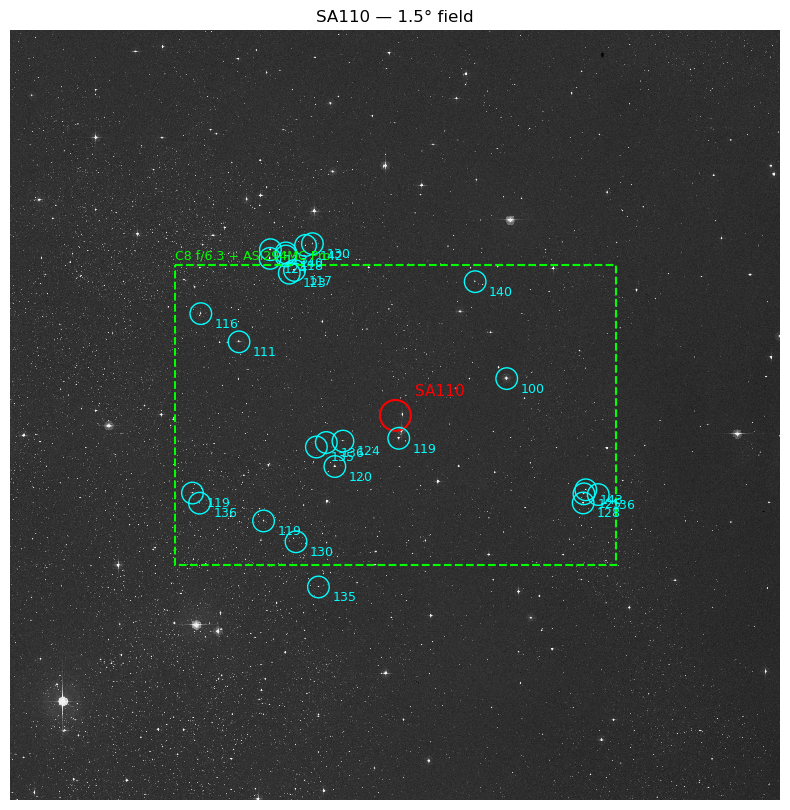

In [9]:
# Cell 9 — AAVSO comparison stars + finder-chart plot (with equipment FOV overlay)
#
# Pulls the standard AAVSO photometric comparison-star sequence for the field
# (AAVSO VSP — Variable Star Plotter, a separate service from the VSX lookup
# used earlier), plots it alongside the target star on the DSS image, and
# overlays the actual imaging equipment's field-of-view rectangle.

from matplotlib.patches import Rectangle

VSP_API_URL = "https://app.aavso.org/vsp/api/chart/"
FINDER_CHART_MAGLIMIT = 14.5   # comparison stars fainter than this rarely help visually
STD_FIELD_CACHE_MAX_STARS = 30 # cap so a standard-field's dense sequence stays legible


def sexagesimal_to_deg(value, is_ra):
    """Parse VSP's 'HH:MM:SS.SS' (ra) or '+DD:MM:SS.S' (dec) strings to decimal degrees."""
    sign = -1.0 if value.strip().startswith("-") else 1.0
    parts = [abs(float(p)) for p in value.replace("+", "").replace("-", "").split(":")]
    d, m, s = (parts + [0, 0, 0])[:3]
    deg = d + m / 60 + s / 3600
    if is_ra:
        deg *= 15.0   # hours -> degrees
    return sign * deg


def fetch_comparison_stars(ra_deg, dec_deg, fov_arcmin, maglimit=FINDER_CHART_MAGLIMIT, special=None):
    """Query AAVSO VSP for the comparison-star sequence centered on (ra_deg, dec_deg).

    special="std_field" switches VSP from its usual sparse comparison-star sequence to the
    full AAVSO Standard Field photometric sequence (hundreds of stars with multi-band
    U/B/V/Rc/Ic photometry) — used for standard_field-type objects, not variable stars.
    """
    params = {"ra": ra_deg, "dec": dec_deg, "fov": fov_arcmin, "maglimit": maglimit, "format": "json"}
    if special:
        params["special"] = special
    resp = requests.get(VSP_API_URL, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    comp_stars = []
    for star in data.get("photometry", []):
        bands = {b["band"]: b["mag"] for b in star.get("bands", [])}
        mag = bands.get("V", next(iter(bands.values()), None))
        entry = {
            "auid": star["auid"],
            "ra": sexagesimal_to_deg(star["ra"], is_ra=True),
            "dec": sexagesimal_to_deg(star["dec"], is_ra=False),
            "label": star["label"],   # AAVSO chart label, e.g. "89" == mag 8.9
            "mag": mag,
        }
        if special:
            entry["bands"] = bands   # multi-band photometry, only needed for transform calcs
        comp_stars.append(entry)
    return comp_stars


def fetch_stars_for_row(row, fov_arcmin_variable=None, maglimit=FINDER_CHART_MAGLIMIT):
    """Dispatches to the right VSP query for a vs.json row: the dense std-field sequence
    (sized to the field's own native FOV, capped/sorted brightest-first) for standard_field
    rows, or the ordinary sparse comparison-star sequence for variable-star rows."""
    ra_deg = row["ra"] * 15.0   # df stores ra in decimal hours
    dec_deg = row["dec"]

    if row["type"] == "standard_field":
        field = fetch_std_fields()[row["displayName"].strip().lower()]
        comp_stars = fetch_comparison_stars(
            ra_deg, dec_deg,
            fov_arcmin=float(field["Fov"]),
            maglimit=maglimit,
            special="std_field",
        )
        comp_stars.sort(key=lambda s: (s["mag"] is None, s["mag"]))   # brightest first
        return comp_stars[:STD_FIELD_CACHE_MAX_STARS]

    return fetch_comparison_stars(ra_deg, dec_deg, fov_arcmin=fov_arcmin_variable, maglimit=maglimit)


def compute_fov_deg(equipment):
    """Returns (fov_w_deg, fov_h_deg) for an equipment dict with focal_length_mm
    (effective, i.e. any reducer already applied), pixel_size_um, resolution_width,
    resolution_height."""
    fl = equipment["focal_length_mm"]
    sensor_w_mm = equipment["pixel_size_um"] * equipment["resolution_width"] / 1000.0
    sensor_h_mm = equipment["pixel_size_um"] * equipment["resolution_height"] / 1000.0
    fov_w_deg = 2.0 * math.degrees(math.atan(sensor_w_mm / (2.0 * fl)))
    fov_h_deg = 2.0 * math.degrees(math.atan(sensor_h_mm / (2.0 * fl)))
    return fov_w_deg, fov_h_deg


def plot_finder_chart(object_id, size_deg=FINDER_CHART_SIZE_DEG, maglimit=FINDER_CHART_MAGLIMIT,
                       show_comparison_stars=True, equipment=None):
    row = df[df["objectId"] == object_id].iloc[0]
    center_ra_deg = row["ra"] * 15.0   # vs.json/df store ra in decimal hours
    center_dec_deg = row["dec"]

    image = fetch_dss_image(center_ra_deg, center_dec_deg, size_deg=size_deg)

    # figsize * dpi == image pixel size, so imshow draws 1:1 with no resampling blur
    dpi = 100
    fig, ax = plt.subplots(figsize=(FINDER_CHART_PIXELS / dpi, FINDER_CHART_PIXELS / dpi), dpi=dpi)
    ax.imshow(image, cmap="gray", interpolation="nearest")

    px, py = radec_to_pixel(center_ra_deg, center_dec_deg, center_ra_deg, center_dec_deg, size_deg)
    ax.add_patch(Circle((px, py), radius=20, edgecolor="red", facecolor="none", linewidth=1.5))
    ax.annotate(row["displayName"], (px, py), xytext=(px + 25, py - 25), color="red", fontsize=11)

    if show_comparison_stars:
        comp_stars = fetch_stars_for_row(row, fov_arcmin_variable=size_deg * 60, maglimit=maglimit)
        for star in comp_stars:
            cx, cy = radec_to_pixel(star["ra"], star["dec"], center_ra_deg, center_dec_deg, size_deg)
            if not (0 <= cx < FINDER_CHART_PIXELS and 0 <= cy < FINDER_CHART_PIXELS):
                continue   # VSP's fov is a radius/diagonal, so it can return stars outside our square cutout
            ax.add_patch(Circle((cx, cy), radius=14, edgecolor="cyan", facecolor="none", linewidth=1))
            ax.annotate(star["label"], (cx, cy), xytext=(cx + 18, cy + 18), color="cyan", fontsize=9)
        comp_stars
        print(f"Plotted {len(comp_stars)} AAVSO comparison stars (maglimit={maglimit}).")

    if equipment is not None:
        deg_per_px = size_deg / FINDER_CHART_PIXELS
        fov_w_deg, fov_h_deg = compute_fov_deg(equipment)
        if fov_w_deg > size_deg or fov_h_deg > size_deg:
            print(f"Warning: {equipment['name']} FOV ({fov_w_deg:.2f}°x{fov_h_deg:.2f}°) "
                  f"exceeds the fetched field ({size_deg}°) — increase size_deg to see the full box.")
        w_px, h_px = fov_w_deg / deg_per_px, fov_h_deg / deg_per_px
        ax.add_patch(Rectangle((px - w_px / 2, py - h_px / 2), w_px, h_px,
                                edgecolor="lime", facecolor="none", linewidth=1.5, linestyle="--"))
        ax.text(px - w_px / 2, py - h_px / 2 - 8, equipment["name"], color="lime", fontsize=9)

    ax.set_title(f"{row['displayName']} — {size_deg}° field")
    ax.axis("off")
    plt.show()


# C8 + f/6.3 reducer (effective focal length already includes the reducer) + ASI294MC Pro
C8_ASI294MC = {
    "name": "C8 f/6.3 + ASI294MC Pro",
    "focal_length_mm": 1280,
    "pixel_size_um": 4.63,
    "resolution_width": 4144,
    "resolution_height": 2822,
}

fov_w_deg, fov_h_deg = compute_fov_deg(C8_ASI294MC)
print(f"{C8_ASI294MC['name']} FOV: {fov_w_deg:.3f}° x {fov_h_deg:.3f}°")

plot_finder_chart("sa110", equipment=C8_ASI294MC)


In [10]:
# Cell 9b — Generate offline comparison-star cache (mobile/comp_stars/<objectId>.json)
#
# field_check.ipynb runs in the field with no internet, so it can't call AAVSO VSP
# directly. Instead we fetch a generous comparison-star window for every star here
# (at catalog-build time, with internet) and cache it per-object, reusing
# fetch_stars_for_row defined above (same dispatch logic used by plot_finder_chart,
# so the cache always matches what the notebook's own chart shows).
#
# standard_field objects (e.g. M11) use a different query: special="std_field" pulls
# AAVSO's own dense photometric sequence (hundreds of stars) sized to the field's own
# native FOV (from the api.std_fields catalog) rather than the generic 2.0° window used
# for variable stars — that generic window was scooping in stars far outside any real
# telescope's frame, which doesn't make sense for a calibration field. The full sequence
# is capped to the STD_FIELD_CACHE_MAX_STARS brightest stars so the chart stays legible.
#
# These files are published via GitHub Pages alongside vs.json/dso.json, so the
# AstroPlanner app can consume them too — see comp_stars_json_spec.md.

import os

COMP_STARS_DIR = "mobile/comp_stars"
COMP_STAR_CACHE_FOV_DEG = 2.0     # diagonal field size to cache per variable-star target —
                                   # comfortably covers real equipment FOV (~1°) plus dither/drift
COMP_STAR_CACHE_MAGLIMIT = 14.5

os.makedirs(COMP_STARS_DIR, exist_ok=True)

for _, row in df.iterrows():
    comp_stars = fetch_stars_for_row(
        row,
        fov_arcmin_variable=COMP_STAR_CACHE_FOV_DEG * 60,
        maglimit=COMP_STAR_CACHE_MAGLIMIT,
    )

    for star in comp_stars:
        star["ra"] = star["ra"] / 15.0   # store in decimal hours, matching vs.json's convention

    out_path = os.path.join(COMP_STARS_DIR, f"{row['objectId']}.json")
    with open(out_path, "w") as f:
        json.dump(comp_stars, f, indent=2)
    print(f"{row['objectId']}: cached {len(comp_stars)} comparison stars -> {out_path}")


cyaqr: cached 16 comparison stars -> mobile/comp_stars/cyaqr.json
yzboo: cached 30 comparison stars -> mobile/comp_stars/yzboo.json
wuma: cached 11 comparison stars -> mobile/comp_stars/wuma.json
sa110: cached 26 comparison stars -> mobile/comp_stars/sa110.json
